### **<font color="blue">Iris Dataset</font>**

Perceptron Train Acc: 100.00%
Perceptron Test  Acc: 95.56%
Logistic  Train Acc: 100.00%
Logistic  Test  Acc: 100.00%
Perceptron weights (bias, w1, w2): [-0.46   0.446 -0.678]
Logistic coef, intercept: [[ 3.1361 -2.6125]] [-8.6525]
Saved interactive Plotly HTML to: ML37_03Perceptron_vs_logistic_plotly.html


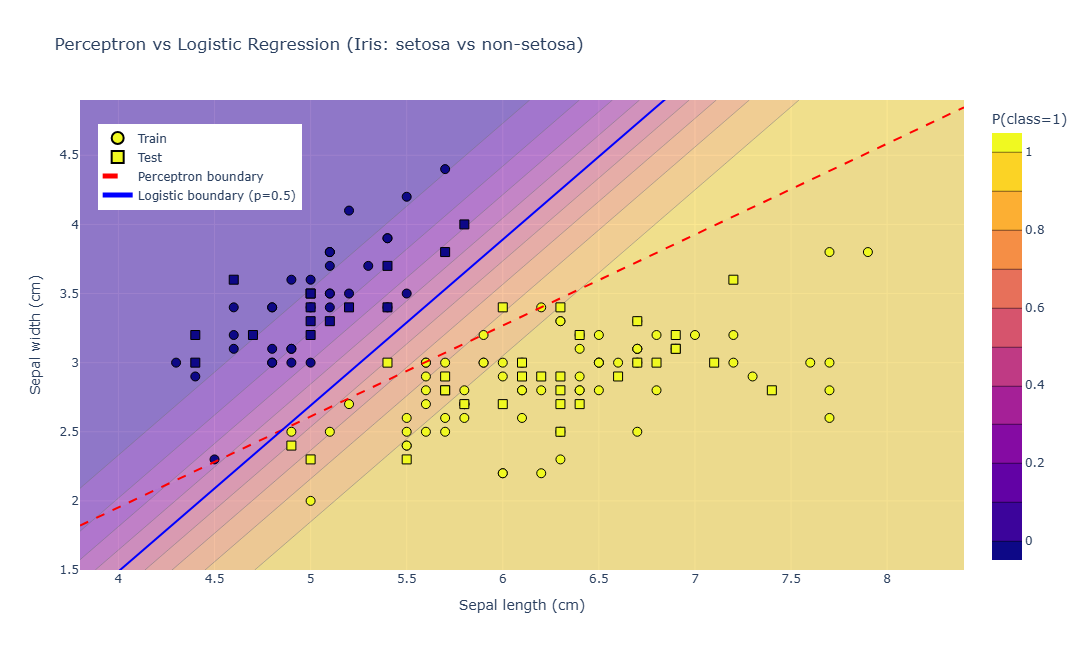

In [1]:
"""
Perceptron vs Logistic Regression (Iris, 2D) — Plotly version
Saves interactive plot to /mnt/data/perceptron_vs_logistic_plotly.html
"""
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -------------------------------
# Data
# -------------------------------
iris = load_iris()
X = iris.data[:, :2]                 # sepal length & width
y = (iris.target != 0).astype(int)   # setosa vs non-setosa (binary)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ================================================================
# Perceptron (simple implementation)
# ================================================================
def perceptron_train(X_train, y_train, lr=0.01, epochs=1000):
    Xb = np.insert(X_train, 0, 1, axis=1).astype(float)  # bias column
    w = np.zeros(Xb.shape[1], dtype=float)
    for _ in range(epochs):
        updates = 0
        for xi, yi in zip(Xb, y_train):
            y_hat = 1 if np.dot(xi, w) >= 0 else 0
            delta = lr * (yi - y_hat)
            if delta != 0:
                w += delta * xi
                updates += 1
        if updates == 0:
            break
    return w

def perceptron_predict(X, w):
    Xb = np.insert(X, 0, 1, axis=1).astype(float)
    return (np.dot(Xb, w) >= 0).astype(int)

w_perc = perceptron_train(X_train, y_train, lr=0.01, epochs=1000)
train_preds_perc = perceptron_predict(X_train, w_perc)
test_preds_perc = perceptron_predict(X_test, w_perc)

perc_train_acc = accuracy_score(y_train, train_preds_perc)
perc_test_acc  = accuracy_score(y_test, test_preds_perc)

# ================================================================
# Logistic Regression
# ================================================================
lr = LogisticRegression(solver='lbfgs')
lr.fit(X_train, y_train)
train_preds_lr = lr.predict(X_train)
test_preds_lr  = lr.predict(X_test)

lr_train_acc = accuracy_score(y_train, train_preds_lr)
lr_test_acc  = accuracy_score(y_test, test_preds_lr)

print(f"Perceptron Train Acc: {perc_train_acc*100:.2f}%")
print(f"Perceptron Test  Acc: {perc_test_acc*100:.2f}%")
print(f"Logistic  Train Acc: {lr_train_acc*100:.2f}%")
print(f"Logistic  Test  Acc: {lr_test_acc*100:.2f}%")
print("Perceptron weights (bias, w1, w2):", np.round(w_perc, 4))
print("Logistic coef, intercept:", np.round(lr.coef_,4), np.round(lr.intercept_,4))

# ================================================================
# Grid for background regions & probabilities
# ================================================================
pad = 0.5
x_min, x_max = X[:,0].min() - pad, X[:,0].max() + pad
y_min, y_max = X[:,1].min() - pad, X[:,1].max() + pad

nx, ny = 300, 300
xs = np.linspace(x_min, x_max, nx)
ys = np.linspace(y_min, y_max, ny)
xx, yy = np.meshgrid(xs, ys)             # shape (ny, nx)
grid = np.c_[xx.ravel(), yy.ravel()]

Z_perc = perceptron_predict(grid, w_perc).reshape(xx.shape)      # 0/1 region
Z_logr_prob = lr.predict_proba(grid)[:,1].reshape(xx.shape)     # probability of class 1

# ================================================================
# Create Plotly figure
# ================================================================
fig = go.Figure()

# Perceptron region as semi-transparent heatmap (0/1)
fig.add_trace(go.Heatmap(
    x=xs, y=ys, z=Z_perc,
    colorscale=[[0.0, 'rgba(200,200,255,0.0)'], [1.0, 'rgba(200,200,255,0.25)']],
    hoverinfo='none',
    showscale=False,
    zmin=0, zmax=1,
    name='Perceptron region'
))

# Logistic probability contour (smooth)
fig.add_trace(go.Contour(
    x=xs, y=ys, z=Z_logr_prob,
    contours=dict(start=0.0, end=1.0, size=0.1),
    showscale=True,
    colorbar=dict(title='P(class=1)'),
    opacity=0.5,
    name='Logistic prob'
))

# Scatter: training points
fig.add_trace(go.Scatter(
    x=X_train[:,0], y=X_train[:,1],
    mode='markers',
    marker=dict(symbol='circle', size=9, line=dict(width=1, color='black')),
    name='Train',
    text=[f"train idx:{i}" for i in range(len(X_train))],
    hovertemplate='(%{x:.2f}, %{y:.2f})<br>class=%{marker.color}<extra>train</extra>',
    marker_color=y_train
))

# Scatter: testing points
fig.add_trace(go.Scatter(
    x=X_test[:,0], y=X_test[:,1],
    mode='markers',
    marker=dict(symbol='square', size=9, line=dict(width=1, color='black')),
    name='Test',
    text=[f"test idx:{i}" for i in range(len(X_test))],
    hovertemplate='(%{x:.2f}, %{y:.2f})<br>class=%{marker.color}<extra>test</extra>',
    marker_color=y_test
))

# Perceptron decision boundary (line or vertical)
b, w1, w2 = w_perc
if abs(w2) > 1e-8:
    x_line = np.array([x_min, x_max])
    y_line = -(b + w1 * x_line) / w2
    fig.add_trace(go.Scatter(
        x=x_line, y=y_line, mode='lines',
        line=dict(color='red', dash='dash', width=2),
        name='Perceptron boundary'
    ))
else:
    # vertical line
    x_vert = -b / w1 if abs(w1) > 1e-8 else None
    if x_vert is not None:
        fig.add_trace(go.Scatter(
            x=[x_vert, x_vert], y=[y_min, y_max], mode='lines',
            line=dict(color='red', dash='dash', width=2),
            name='Perceptron boundary'
        ))

# Logistic regression decision boundary (probability 0.5)
coef = lr.coef_[0]
intercept = lr.intercept_[0]
if abs(coef[1]) > 1e-8:
    x_line = np.array([x_min, x_max])
    y_line = -(intercept + coef[0]*x_line) / coef[1]
    fig.add_trace(go.Scatter(
        x=x_line, y=y_line, mode='lines',
        line=dict(color='blue', dash='solid', width=2),
        name='Logistic boundary (p=0.5)'
    ))
else:
    x_vert = -intercept / coef[0] if abs(coef[0]) > 1e-8 else None
    if x_vert is not None:
        fig.add_trace(go.Scatter(
            x=[x_vert, x_vert], y=[y_min, y_max], mode='lines',
            line=dict(color='blue', dash='solid', width=2),
            name='Logistic boundary (p=0.5)'
        ))

# Layout
fig.update_layout(
    title="Perceptron vs Logistic Regression (Iris: setosa vs non-setosa)",
    xaxis_title="Sepal length (cm)",
    yaxis_title="Sepal width (cm)",
    legend=dict(itemsizing='constant', yanchor='top', y=0.95, xanchor='left', x=0.02),
    width=900, height=650
)

fig.update_xaxes(range=[x_min, x_max])
fig.update_yaxes(range=[y_min, y_max])

# Save interactive HTML and show
out_path = "ML37_03Perceptron_vs_logistic_plotly.html"
fig.write_html(out_path)
print("Saved interactive Plotly HTML to:", out_path)

fig.show()
